In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import linalg as la

from jax.numpy import einsum

#for coloring lines
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import blochK
import blochK.observable as observable
from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import extent
from blochK.plotting.publication import paper_style,paper_style_small, revtex_textwidth, revtex_columnwidth, set_size
from blochK.observable import conductivity_orbital_resolved

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D, create_H_DLKK_3D_MF
from alter_surf.utils3D import projector2layer

import pickle

%load_ext autoreload
%autoreload 2



In [2]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

make the colormaps


In [3]:
from matplotlib.colors import LinearSegmentedColormap

bwr_map = matplotlib.colormaps["bwr"]

cmap_bwr = matplotlib.colormaps["bwr"]
colors = [cmap_bwr(0.0), (0, 0, 0, 1), cmap_bwr(1.0)]
cmap_bkr = LinearSegmentedColormap.from_list("bkr", colors, N=256)


def two_param_color(x, y, a=0.5):
    """
    x ∈ [0,1]: blue → black → red
    y ∈ [0,1]: base color → white
    """
    base = np.array(cmap_bkr(x)) * np.array([1, 1, 1, 1])  # RGB only
    white = np.ones((*x.shape, 4)) * np.array([1, 1, 1, 1])

    y_scaled = 2 * (1 - y) * y * a + y * y

    y_expanded = y_scaled[..., np.newaxis] * np.array([1, 1, 1, 1])
    rgb = base * y_expanded + white * (1 - y_expanded)

    return rgb


nx, ny = 300, 300
img = np.zeros((ny, nx, 4))


X, Y = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))
img = two_param_color(X, Y, 1)


# plt.imshow(img, origin="lower", aspect="auto")
# plt.xlabel("x: blue → black → red")
# plt.ylabel("y: base → white")
# plt.show()

In [ ]:
Hparam = dict(len_z=30, delta=1, tp=0.3, tz=1, PBC=False, mAF=3, mu=3.1)
# create Hamiltonian with MF parameters
H_DLKK = create_H_DLKK_3D(param=Hparam)

Hparam_3d = dict(len_z=30, delta=1, tp=0.3, tz=1, PBC=True, mAF=3, mu=3.1)

In [5]:
def spec_func(psis, es, e_vals, eta, proj):

    greens_diag = 1 / ((es + 1j * eta)[..., None] - e_vals[None, :])

    greens = einsum(
        "j...i,j...g,j...k -> ik...g", psis, greens_diag, psis.conj()
    )  # indices are matrix(i,j), momenta, energy

    # hit it with the projector
    spec = -(1 / np.pi) * einsum("ii...g,i-> ...g", greens, proj).imag
    return spec

In [6]:
# make a path from Γ to X to M to Y to Γ
n_k = 200
path = np.array([[1, 1], [0, 1], [0, 0], [1, 0], [1, 1]])
k_walk = (
    np.concatenate(
        [
            np.linspace(path[i], path[i + 1], n_k, endpoint=False)
            for i in range(len(path) - 1)
        ]
    )
    * np.pi
)
k_labels = [r"$M$", r"$Y$", r"$\Gamma$", r"$X$", r"$M$"]
label_positions = np.linspace(0, len(k_walk), len(k_labels)).astype(int)

# diagonalise along the k_walk
es, psis = H_DLKK.diagonalize(*k_walk.T)

In [7]:
e_vals = np.linspace(np.min(es), np.max(es), 200)
eta = 1e-1
n_layers = Hparam["len_z"]

# make the spectral function in the boundary
chosen_layer = 0
p_l = np.zeros(n_layers)
p_l[chosen_layer] = 1
p_l[chosen_layer + 1] = 1
proj_same = np.kron(p_l, np.array([1, 1, 1, 1]))
proj_diff = np.kron(p_l, np.array([1, 1, -1, -1]))
spec_same_boundary_walk = spec_func(psis, es, e_vals, eta, proj_same).T
spec_diff_boundary_walk = spec_func(psis, es, e_vals, eta, proj_diff).T


# make the spectral function in the bulk
chosen_layer = 10
p_l = np.zeros(n_layers)
p_l[chosen_layer] = 1
p_l[chosen_layer + 1] = 1
# pl = np.eye(p_l.shape[0])
proj_same = np.kron(p_l, np.array([1, 1, 1, 1]))
proj_diff = np.kron(p_l, np.array([1, 1, -1, -1]))
spec_same_bulk_walk = spec_func(psis, es, e_vals, eta, proj_same).T
spec_diff_bulk_walk = spec_func(psis, es, e_vals, eta, proj_diff).T


# normalize all together
spec_diff_walk_norm = Normalize(
    np.min([spec_diff_boundary_walk, spec_diff_bulk_walk]),
    np.max([spec_diff_boundary_walk, spec_diff_bulk_walk]),
)
spec_same_walk_norm = Normalize(
    np.min([spec_same_boundary_walk, spec_same_bulk_walk]),
    np.max([spec_same_boundary_walk, spec_same_bulk_walk]),
)


# find colors
colors_bulk_walk = two_param_color(
    spec_diff_walk_norm(spec_diff_bulk_walk),
    spec_same_walk_norm(spec_same_bulk_walk),
    1,
)
colors_boundary_walk = two_param_color(
    spec_diff_walk_norm(spec_diff_boundary_walk),
    spec_same_walk_norm(spec_same_boundary_walk),
    1,
)

Make the plots for the horizontal slices


In [8]:
spillover = 0.25

n_k_grid = 101

k_values = np.linspace(
    -np.pi * (1 + spillover), np.pi * (1 + spillover), n_k_grid, endpoint=False
)

KX, KY = np.meshgrid(k_values, k_values)

es, psis = H_DLKK.diagonalize(KX, KY)

In [ ]:
# make the spectral function
fermi_level = np.array([0])
eta = 1e-1
n_layers = Hparam["len_z"]


# for boundary
chosen_layer = 0
p_l = np.zeros(n_layers)
p_l[chosen_layer] = 1
p_l[chosen_layer + 1] = 1
spec_same_boundary = np.kron(p_l, np.array([1, 1, 1, 1]))
proj_diff_bulk = np.kron(p_l, np.array([1, 1, -1, -1]))
spec_same_boundary = spec_func(psis, es, fermi_level, eta, spec_same_boundary).T[0]
spec_diff_boundary = spec_func(psis, es, fermi_level, eta, proj_diff_bulk).T[0]

# for bulk
chosen_layer = 10
p_l = np.zeros(n_layers)
p_l[chosen_layer] = 1
p_l[chosen_layer + 1] = 1
spec_same_bulk = np.kron(p_l, np.array([1, 1, 1, 1]))
spec_diff_bulk = np.kron(p_l, np.array([1, 1, -1, -1]))
spec_same_bulk = spec_func(psis, es, fermi_level, eta, spec_same_bulk).T[0]
spec_diff_bulk = spec_func(psis, es, fermi_level, eta, spec_diff_bulk).T[0]

# global normalization
norm_diff = Normalize(
    min(np.min(spec_diff_boundary), np.min(spec_diff_bulk)),
    max(np.max(spec_diff_boundary), np.max(spec_diff_bulk)),
)
norm_same = Normalize(
    min(np.min(spec_same_boundary), np.min(spec_same_bulk)),
    max(np.max(spec_same_boundary), np.max(spec_same_bulk)),
)

colors_boundary = two_param_color(
    norm_diff(spec_diff_boundary), norm_same(spec_same_boundary), 1
)
colors_bulk = two_param_color(norm_diff(spec_diff_bulk), norm_same(spec_same_bulk), 1)

In [ ]:
# spin splitter

cond_tensor = conductivity_orbital_resolved(
    H_DLKK, Lk=40, optimize="path"
)  # .shape=(localH,x,y)

sum_layers = 2  # sum always n_layers layers up
len_z = Hparam["len_z"]


cond_tensor2 = np.reshape(
    cond_tensor, (len_z, 2, 2, 2, 2)
)  # .shape=(layer,spin,sublattice,x,y)
cond_tensor2 = cond_tensor2.reshape(
    -1, sum_layers, 2, 2, 2, 2
)  # .shape=(layer/sum_layers,sum_layers,sublattice,spin,x,y)

cond_xx = np.sum(
    cond_tensor2[:, :, :, :, 0, 0], axis=(1, 3)
)  # .shape=(layer/sum_layers,spin)
spin_cond_xx = cond_xx[:, 0] - cond_xx[:, 1]  # difference of spin indices
cond0_xx = cond_xx[:, 0] + cond_xx[:, 1]  # total cond: sum of spin indices
# indices is fixed by sum_layers
layers = np.arange(0, len_z + 1 - sum_layers, sum_layers)

plot it all

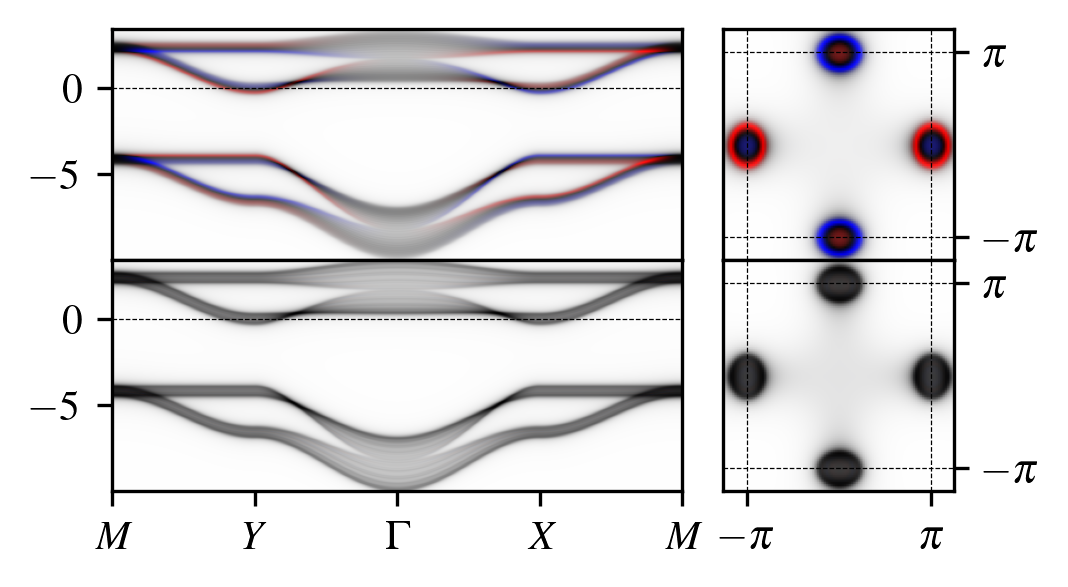

In [17]:
from matplotlib.gridspec import GridSpec

w = 2.3
h = 1.0
wspace = 0.08

fig = plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth * ((h + 1) / (w + 1 + wspace))), dpi=300
)
gs = GridSpec(
    2, 2, width_ratios=[w, h], height_ratios=[1, 1], wspace=wspace, hspace=0.0
)

# Left column (share x and y)
ax_l1 = fig.add_subplot(gs[0, 0])
ax_l2 = fig.add_subplot(gs[1, 0], sharex=ax_l1, sharey=ax_l1)

# Right column (share x and y)
ax_r1 = fig.add_subplot(gs[0, 1])
ax_r2 = fig.add_subplot(gs[1, 1], sharex=ax_r1, sharey=ax_r1)


ax_l1.imshow(
    colors_boundary_walk,
    extent=(0, len(k_walk), e_vals[0], e_vals[-1]),
    aspect="auto",
    # interpolation='nearest',
    origin="lower",
)

ax_l2.imshow(
    colors_bulk_walk,
    extent=(0, len(k_walk), e_vals[0], e_vals[-1]),
    aspect="auto",
    # interpolation='nearest',
    origin="lower",
)


ax_r1.imshow(
    colors_boundary.reshape(n_k_grid, n_k_grid, 4),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)

ax_r2.imshow(
    colors_bulk.reshape(n_k_grid, n_k_grid, 4),
    extent=(
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
        -np.pi * (1 + spillover),
        np.pi * (1 + spillover),
    ),
)


for a in (ax_r1, ax_r2):
    a.axhline(-np.pi, color="k", ls="--", lw=0.3)
    a.axhline(np.pi, color="k", ls="--", lw=0.3)
    a.axvline(-np.pi, color="k", ls="--", lw=0.3)
    a.axvline(np.pi, color="k", ls="--", lw=0.3)

ax_l1.tick_params(
    axis="both",
    which="both",
    bottom=False,
    top=False,
    left=True,
    right=False,
    labelbottom=False,
    labelleft=True,
)
ax_r1.tick_params(
    axis="both",
    which="both",
    bottom=False,
    top=False,
    left=False,
    right=True,
    labelbottom=False,
    labelright=True,
    labelleft=False,
)
ax_r2.tick_params(
    axis="both",
    which="both",
    bottom=True,
    top=False,
    left=False,
    right=True,
    labelbottom=True,
    labelright=True,
    labelleft=False,
)

fig.subplots_adjust(left=0.08, right=0.92)

ax_l2.set_xticks(label_positions, k_labels)
ax_l1.axhline(0, color="k", ls="--", lw=0.3)
ax_l2.axhline(0, color="k", ls="--", lw=0.3)

ax_r2.set_xticks([-np.pi, np.pi])
ax_r2.set_yticks([-np.pi, np.pi])
ax_r2.set_yticklabels(["$-\\pi$", "$\\pi$"])
ax_r2.set_xticklabels(["$-\\pi$", "$\\pi$"])


plt.savefig("spec_dlkk.png", bbox_inches="tight", transparent=True, dpi=350)

In [ ]:
from blochK.observable import (
    exp_value_O,
    conductivity_orbital_resolved,
    local_dos_QPI,
    find_Gamma,
)

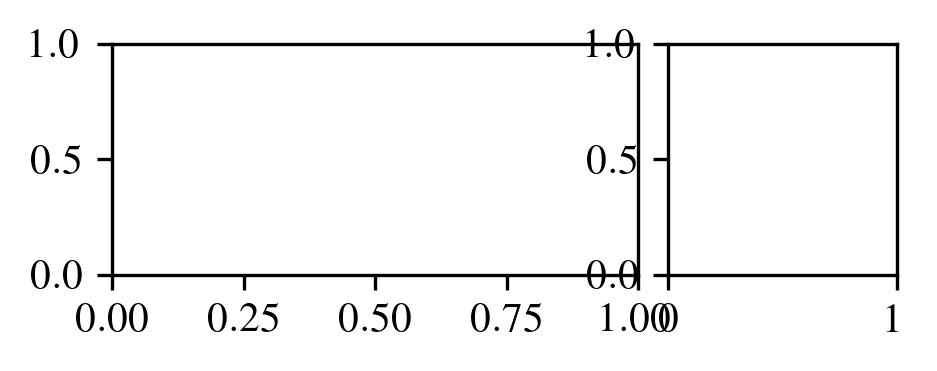

In [ ]:
fig = plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth * ((h + 1) / (w + 1 + wspace)) / 2), dpi=300
)
gs = GridSpec(1, 2, width_ratios=[w, h], wspace=wspace, hspace=0.0)

# Left column (share x and y)
ax_l1 = fig.add_subplot(gs[0])
ax_l2 = fig.add_subplot(gs[1])

labels = ["Y", "X", "\\Gamma", "Y", "M", "R", "Y", "Z"]